In [1]:
import pandas as pd

In [2]:
import pandas as pd

print("Pandas is working!")

Pandas is working!


In [3]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
file_path = r"C:\Users\DELL\Downloads\Personalized_Healthcare_Dataset\Healthcare.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 25000
Number of columns: 6


In [8]:
df.head()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [9]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Patient_ID', 'Age', 'Gender', 'Symptoms', 'Symptom_Count', 'Disease']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Patient_ID     25000 non-null  int64
 1   Age            25000 non-null  int64
 2   Gender         25000 non-null  str  
 3   Symptoms       25000 non-null  str  
 4   Symptom_Count  25000 non-null  int64
 5   Disease        25000 non-null  str  
dtypes: int64(3), str(3)
memory usage: 2.8 MB


In [11]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
print("Number of unique diseases:", df["Disease"].nunique())

Number of unique diseases: 30


In [14]:
print("Diseases in the dataset:")
print(df["Disease"].unique())

Diseases in the dataset:
<ArrowStringArray>
[               'Allergy',       'Thyroid Disorder',              'Influenza',
                 'Stroke',          'Heart Disease',         'Food Poisoning',
             'Bronchitis',               'COVID-19',             'Dermatitis',
               'Diabetes',              'Arthritis',              'Sinusitis',
               'Dementia',            'Parkinson's',                'Obesity',
                 'Asthma',             'Depression',              'Gastritis',
          'Liver Disease',               'Epilepsy',                    'IBS',
           'Tuberculosis',              'Pneumonia',                 'Anemia',
               'Migraine',            'Common Cold',                'Anxiety',
 'Chronic Kidney Disease',                  'Ulcer',           'Hypertension']
Length: 30, dtype: str


In [15]:
disease_counts = df["Disease"].value_counts()

print(disease_counts)

Disease
Anxiety                   911
Arthritis                 896
Food Poisoning            871
Depression                859
Allergy                   858
Bronchitis                856
Dermatitis                856
Thyroid Disorder          855
Migraine                  854
Diabetes                  850
COVID-19                  839
Ulcer                     833
Hypertension              833
Epilepsy                  832
Liver Disease             830
IBS                       830
Pneumonia                 830
Parkinson's               826
Influenza                 824
Dementia                  823
Obesity                   819
Tuberculosis              814
Anemia                    814
Chronic Kidney Disease    807
Common Cold               805
Heart Disease             804
Gastritis                 804
Sinusitis                 795
Stroke                    790
Asthma                    782
Name: count, dtype: int64


In [16]:
print("Minimum age:", df["Age"].min())
print("Maximum age:", df["Age"].max())
print("Average age:", round(df["Age"].mean(), 2))

Minimum age: 1
Maximum age: 90
Average age: 45.3


In [17]:
print(df["Gender"].value_counts())

Gender
Other     8393
Female    8336
Male      8271
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Machine learning libraries imported!")

Machine learning libraries imported!


In [19]:
X = df["Symptoms"]
y = df["Disease"]

print("Input feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Input feature:
0                fever, back pain, shortness of breath
1                     insomnia, back pain, weight loss
2                      sore throat, vomiting, diarrhea
3    blurred vision, depression, weight loss, muscl...
4                      swelling, appetite loss, nausea
Name: Symptoms, dtype: str

Target:
0             Allergy
1    Thyroid Disorder
2           Influenza
3              Stroke
4       Heart Disease
Name: Disease, dtype: str


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 20000
Testing records: 5000


In [21]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (20000, 35)
Testing feature shape: (5000, 35)


In [22]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 3.22 %


In [25]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

               Allergy       0.05      0.05      0.05       172
                Anemia       0.03      0.03      0.03       163
               Anxiety       0.01      0.02      0.02       182
             Arthritis       0.02      0.02      0.02       179
                Asthma       0.02      0.02      0.02       156
            Bronchitis       0.03      0.04      0.03       171
              COVID-19       0.05      0.05      0.05       168
Chronic Kidney Disease       0.06      0.06      0.06       161
           Common Cold       0.02      0.02      0.02       161
              Dementia       0.02      0.02      0.02       165
            Depression       0.04      0.03      0.04       172
            Dermatitis       0.05      0.05      0.05       171
              Diabetes       0.05      0.05      0.05       170
              Epilepsy       0.04      0.04      0.04       166
        Food Poisoning       0.05      

In [26]:
# Split symptoms and create a list of individual symptoms
all_symptoms = set()

for symptoms in df["Symptoms"]:
    for symptom in symptoms.split(","):
        all_symptoms.add(symptom.strip().lower())

print("Total unique symptoms:", len(all_symptoms))
print("\nSymptoms:")
print(sorted(all_symptoms))

Total unique symptoms: 28

Symptoms:
['abdominal pain', 'anxiety', 'appetite loss', 'back pain', 'blurred vision', 'chest pain', 'cough', 'depression', 'diarrhea', 'dizziness', 'fatigue', 'fever', 'headache', 'insomnia', 'joint pain', 'muscle pain', 'nausea', 'rash', 'runny nose', 'shortness of breath', 'sneezing', 'sore throat', 'sweating', 'swelling', 'tremors', 'vomiting', 'weight gain', 'weight loss']


In [27]:
from collections import Counter

symptom_counter = Counter()

for symptoms in df["Symptoms"]:
    symptom_list = [s.strip().lower() for s in symptoms.split(",")]
    symptom_counter.update(symptom_list)

print("Most common symptoms:")
print(symptom_counter.most_common(20))

Most common symptoms:
[('appetite loss', 4595), ('sneezing', 4562), ('headache', 4555), ('muscle pain', 4515), ('anxiety', 4506), ('depression', 4497), ('fever', 4496), ('weight loss', 4491), ('swelling', 4490), ('sore throat', 4487), ('blurred vision', 4479), ('fatigue', 4472), ('runny nose', 4468), ('nausea', 4465), ('vomiting', 4464), ('back pain', 4461), ('sweating', 4456), ('shortness of breath', 4454), ('diarrhea', 4449), ('weight gain', 4442)]


In [28]:
allergy_data = df[df["Disease"] == "Allergy"]

print("Number of Allergy records:", len(allergy_data))

display(allergy_data[["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]].head(20))

Number of Allergy records: 858


,Age,Gender,Symptoms,Symptom_Count,Disease
0,29,Male,"fever, back pain, shortness of breath",3,Allergy
133,88,Female,"tremors, weight loss, cough, anxiety, sore thr...",6,Allergy
140,62,Male,"blurred vision, shortness of breath, runny nos...",6,Allergy
145,75,Female,"chest pain, appetite loss, runny nose",3,Allergy
152,39,Other,"depression, sweating, runny nose",3,Allergy
159,9,Other,"fever, cough, appetite loss, dizziness, diarrh...",7,Allergy
167,65,Other,"weight loss, blurred vision, dizziness, joint ...",7,Allergy
195,81,Female,"dizziness, depression, tremors, headache, runn...",7,Allergy
207,44,Female,"abdominal pain, rash, fever, sweating, chest p...",6,Allergy
219,90,Male,"appetite loss, headache, cough, chest pain, sw...",5,Allergy


In [29]:
stroke_data = df[df["Disease"] == "Stroke"]

display(stroke_data[["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]].head(20))

,Age,Gender,Symptoms,Symptom_Count,Disease
3,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
27,81,Male,"weight gain, diarrhea, fever, sore throat",4,Stroke
37,75,Female,"back pain, dizziness, cough",3,Stroke
161,17,Male,"appetite loss, nausea, fatigue, insomnia, tremors",5,Stroke
172,16,Female,"weight gain, weight loss, dizziness",3,Stroke
215,16,Female,"blurred vision, tremors, abdominal pain",3,Stroke
251,75,Male,"abdominal pain, depression, nausea",3,Stroke
257,35,Female,"dizziness, diarrhea, runny nose",3,Stroke
262,34,Other,"tremors, fatigue, muscle pain",3,Stroke
299,15,Other,"nausea, dizziness, tremors, abdominal pain",4,Stroke


In [30]:
print("Checking Allergy records:")
print(df[df["Disease"] == "Allergy"][["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]].head(10))

Checking Allergy records:
     Age  Gender                                           Symptoms  \
0     29    Male              fever, back pain, shortness of breath   
133   88  Female  tremors, weight loss, cough, anxiety, sore thr...   
140   62    Male  blurred vision, shortness of breath, runny nos...   
145   75  Female              chest pain, appetite loss, runny nose   
152   39   Other                   depression, sweating, runny nose   
159    9   Other  fever, cough, appetite loss, dizziness, diarrh...   
167   65   Other  weight loss, blurred vision, dizziness, joint ...   
195   81  Female  dizziness, depression, tremors, headache, runn...   
207   44  Female  abdominal pain, rash, fever, sweating, chest p...   
219   90    Male  appetite loss, headache, cough, chest pain, sw...   

     Symptom_Count  Disease  
0                3  Allergy  
133              6  Allergy  
140              6  Allergy  
145              3  Allergy  
152              3  Allergy  
159         

In [31]:
print("Checking Stroke records:")
print(df[df["Disease"] == "Stroke"][["Age", "Gender", "Symptoms", "Symptom_Count", "Disease"]].head(10))

Checking Stroke records:
     Age  Gender                                           Symptoms  \
3     58   Other  blurred vision, depression, weight loss, muscl...   
27    81    Male          weight gain, diarrhea, fever, sore throat   
37    75  Female                        back pain, dizziness, cough   
161   17    Male  appetite loss, nausea, fatigue, insomnia, tremors   
172   16  Female                weight gain, weight loss, dizziness   
215   16  Female            blurred vision, tremors, abdominal pain   
251   75    Male                 abdominal pain, depression, nausea   
257   35  Female                    dizziness, diarrhea, runny nose   
262   34   Other                      tremors, fatigue, muscle pain   
299   15   Other         nausea, dizziness, tremors, abdominal pain   

     Symptom_Count Disease  
3                4  Stroke  
27               4  Stroke  
37               3  Stroke  
161              5  Stroke  
172              3  Stroke  
215              3 

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert the Symptoms column into lists
symptom_lists = df["Symptoms"].apply(
    lambda x: [s.strip().lower() for s in x.split(",")]
)

# Convert symptoms into binary columns
mlb = MultiLabelBinarizer()

symptom_features = mlb.fit_transform(symptom_lists)

symptom_df = pd.DataFrame(
    symptom_features,
    columns=mlb.classes_,
    index=df.index
)

print("Number of symptom features:", symptom_df.shape[1])

display(symptom_df.head())

Number of symptom features: 28


,abdominal pain,anxiety,appetite loss,back pain,blurred vision,chest pain,cough,depression,diarrhea,dizziness,...,runny nose,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss
0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [33]:
from sklearn.preprocessing import OneHotEncoder

# Encode Gender
gender_encoded = pd.get_dummies(df["Gender"], prefix="Gender", dtype=int)

# Combine all features
X = pd.concat(
    [
        df[["Age", "Symptom_Count"]],
        gender_encoded,
        symptom_df
    ],
    axis=1
)

y = df["Disease"]

print("Final feature shape:", X.shape)
display(X.head())

Final feature shape: (25000, 33)


,Age,Symptom_Count,Gender_Female,Gender_Male,Gender_Other,abdominal pain,anxiety,appetite loss,back pain,blurred vision,...,runny nose,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss
0,29,3,0,1,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,76,3,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,78,3,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,58,4,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
4,55,3,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 20000
Testing records: 5000


In [35]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Improved Random Forest model trained successfully!")

Improved Random Forest model trained successfully!


In [36]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Improved Model Accuracy:", round(accuracy * 100, 2), "%")

Improved Model Accuracy: 3.52 %


In [37]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

               Allergy       0.04      0.05      0.05       172
                Anemia       0.03      0.04      0.04       163
               Anxiety       0.02      0.03      0.03       182
             Arthritis       0.03      0.04      0.04       179
                Asthma       0.02      0.02      0.02       156
            Bronchitis       0.03      0.03      0.03       171
              COVID-19       0.05      0.05      0.05       168
Chronic Kidney Disease       0.02      0.02      0.02       161
           Common Cold       0.04      0.04      0.04       161
              Dementia       0.03      0.02      0.03       165
            Depression       0.04      0.05      0.04       172
            Dermatitis       0.03      0.04      0.03       171
              Diabetes       0.04      0.05      0.05       170
              Epilepsy       0.02      0.02      0.02       166
        Food Poisoning       0.05      

In [38]:
# Show the most common symptoms for each disease

for disease in df["Disease"].unique():
    disease_data = df[df["Disease"] == disease]

    counter = Counter()

    for symptoms in disease_data["Symptoms"]:
        symptom_list = [s.strip().lower() for s in symptoms.split(",")]
        counter.update(symptom_list)

    print("\n" + "=" * 50)
    print(disease)
    print("=" * 50)
    print(counter.most_common(5))


Allergy
[('sneezing', 186), ('nausea', 170), ('muscle pain', 167), ('anxiety', 166), ('fever', 164)]

Thyroid Disorder
[('sweating', 173), ('headache', 165), ('joint pain', 164), ('back pain', 162), ('appetite loss', 162)]

Influenza
[('sweating', 171), ('back pain', 167), ('sore throat', 161), ('insomnia', 160), ('runny nose', 160)]

Stroke
[('insomnia', 164), ('joint pain', 158), ('tremors', 157), ('rash', 155), ('depression', 153)]

Heart Disease
[('fatigue', 164), ('swelling', 153), ('headache', 151), ('abdominal pain', 150), ('chest pain', 148)]

Food Poisoning
[('swelling', 174), ('appetite loss', 172), ('sore throat', 169), ('rash', 167), ('tremors', 166)]

Bronchitis
[('sore throat', 174), ('sweating', 167), ('cough', 167), ('vomiting', 166), ('chest pain', 165)]

COVID-19
[('sneezing', 173), ('headache', 170), ('nausea', 163), ('diarrhea', 159), ('weight loss', 159)]

Dermatitis
[('anxiety', 172), ('fever', 165), ('fatigue', 164), ('swelling', 162), ('sneezing', 158)]

Diabet

In [39]:
fever_data = df[df["Symptoms"].str.contains("fever", case=False, na=False)]

print("Records containing fever:", len(fever_data))

print("\nDiseases associated with fever:")
print(fever_data["Disease"].value_counts())

Records containing fever: 4496

Diseases associated with fever:
Disease
Pneumonia                 174
Anxiety                   172
Chronic Kidney Disease    169
Dermatitis                165
Allergy                   164
Arthritis                 163
Parkinson's               160
Epilepsy                  160
Liver Disease             158
Bronchitis                156
Anemia                    154
Thyroid Disorder          154
Ulcer                     152
Hypertension              151
Tuberculosis              149
Influenza                 148
Common Cold               148
Dementia                  147
Stroke                    144
Migraine                  144
Depression                143
Obesity                   143
COVID-19                  140
Heart Disease             139
IBS                       139
Diabetes                  137
Asthma                    137
Sinusitis                 136
Food Poisoning            136
Gastritis                 114
Name: count, dtype: int64


In [40]:
chest_pain_data = df[
    df["Symptoms"].str.contains("chest pain", case=False, na=False)
]

print("Records containing chest pain:", len(chest_pain_data))

print("\nDiseases associated with chest pain:")
print(chest_pain_data["Disease"].value_counts())

Records containing chest pain: 4414

Diseases associated with chest pain:
Disease
Common Cold               171
Depression                169
Bronchitis                165
Allergy                   158
Diabetes                  156
Food Poisoning            156
Pneumonia                 156
Gastritis                 154
Parkinson's               154
Stroke                    152
Liver Disease             151
Ulcer                     150
Hypertension              150
Anemia                    149
COVID-19                  149
Heart Disease             148
Epilepsy                  146
IBS                       145
Dermatitis                144
Migraine                  144
Obesity                   143
Dementia                  142
Thyroid Disorder          141
Sinusitis                 139
Arthritis                 137
Anxiety                   134
Influenza                 133
Asthma                    128
Tuberculosis              128
Chronic Kidney Disease    122
Name: count, dtype

In [41]:
# Cell 32: Prepare Features

from sklearn.preprocessing import MultiLabelBinarizer

# Convert Symptoms column into lists
symptom_lists = df["Symptoms"].apply(
    lambda x: [s.strip().lower() for s in x.split(",")]
)

# Convert symptoms into binary columns
mlb = MultiLabelBinarizer()
symptom_features = mlb.fit_transform(symptom_lists)

# Create DataFrame
symptom_df = pd.DataFrame(
    symptom_features,
    columns=mlb.classes_
)

# Add Age
symptom_df["Age"] = df["Age"]

# Add Symptom Count
symptom_df["Symptom_Count"] = df["Symptom_Count"]

# Target
y = df["Disease"]

print("Feature shape:", symptom_df.shape)
print("\nFeatures:")
print(symptom_df.columns.tolist())

print("\nTarget classes:", y.nunique())

Feature shape: (25000, 30)

Features:
['abdominal pain', 'anxiety', 'appetite loss', 'back pain', 'blurred vision', 'chest pain', 'cough', 'depression', 'diarrhea', 'dizziness', 'fatigue', 'fever', 'headache', 'insomnia', 'joint pain', 'muscle pain', 'nausea', 'rash', 'runny nose', 'shortness of breath', 'sneezing', 'sore throat', 'sweating', 'swelling', 'tremors', 'vomiting', 'weight gain', 'weight loss', 'Age', 'Symptom_Count']

Target classes: 30


In [42]:
from sklearn.model_selection import train_test_split

X = symptom_df

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 20000
Testing samples: 5000


In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=15
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.0324


In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.0392


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.0384


In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.0304


In [47]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report")
print("=" * 60)

print(classification_report(
    y_test,
    nb_pred,
    zero_division=0
))

Naive Bayes Classification Report
                        precision    recall  f1-score   support

               Allergy       0.01      0.01      0.01       172
                Anemia       0.02      0.04      0.03       163
               Anxiety       0.05      0.08      0.06       182
             Arthritis       0.04      0.08      0.05       179
                Asthma       0.06      0.03      0.04       156
            Bronchitis       0.05      0.06      0.05       171
              COVID-19       0.05      0.05      0.05       168
Chronic Kidney Disease       0.02      0.03      0.03       161
           Common Cold       0.05      0.08      0.06       161
              Dementia       0.03      0.02      0.03       165
            Depression       0.03      0.03      0.03       172
            Dermatitis       0.05      0.04      0.04       171
              Diabetes       0.04      0.02      0.03       170
              Epilepsy       0.05      0.07      0.06       166
     

In [48]:
# Cell 39: Model Comparison

model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        dt_accuracy,
        0.0352,
        nb_accuracy,
        lr_accuracy,
        knn_accuracy
    ]
})

# Convert accuracy to percentage
model_results["Accuracy (%)"] = model_results["Accuracy"] * 100

print(model_results.to_string(index=False))

              Model  Accuracy  Accuracy (%)
      Decision Tree    0.0324          3.24
      Random Forest    0.0352          3.52
        Naive Bayes    0.0392          3.92
Logistic Regression    0.0384          3.84
                KNN    0.0304          3.04


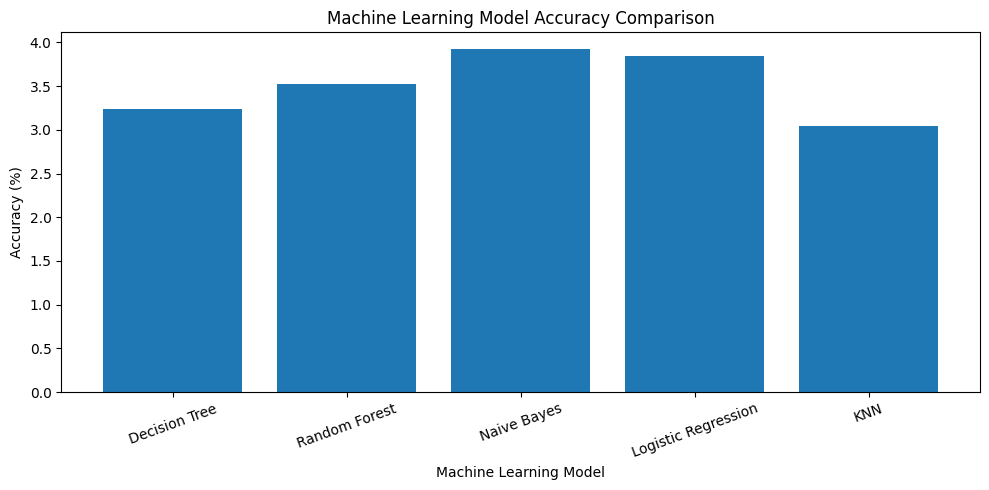

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy (%)"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Machine Learning Model Accuracy Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

<Figure size 1600x1400 with 0 Axes>

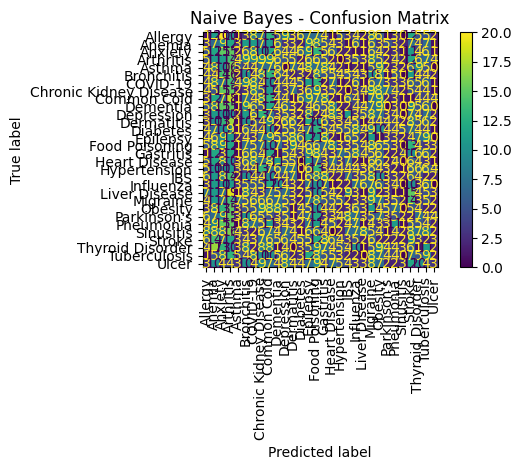

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, nb_pred)

# Display confusion matrix
plt.figure(figsize=(16, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()

In [51]:
# Cell 42: Train Final Model

from sklearn.naive_bayes import GaussianNB

# Create final model
final_model = GaussianNB()

# Train using the complete dataset
final_model.fit(X, y)

print("Final Naive Bayes model trained successfully!")
print("Training records:", len(X))
print("Number of features:", X.shape[1])
print("Number of diseases:", y.nunique())

Final Naive Bayes model trained successfully!
Training records: 25000
Number of features: 30
Number of diseases: 30


In [52]:
# Cell 43: Save Model and Preprocessing Information

import pickle

# Save the trained Naive Bayes model
with open("disease_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

# Save the symptom encoder
with open("symptom_encoder.pkl", "wb") as file:
    pickle.dump(mlb, file)

# Save the feature column names
feature_columns = X.columns.tolist()

with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("Model saved successfully!")
print("Symptom encoder saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Symptom encoder saved successfully!
Feature columns saved successfully!


In [53]:
# Cell 44: Disease Prediction Function

def predict_disease(age, symptoms):
    
    # Create an empty symptom row
    symptom_vector = pd.DataFrame(
        0,
        index=[0],
        columns=mlb.classes_
    )
    
    # Convert entered symptoms to lowercase
    symptoms = [symptom.strip().lower() for symptom in symptoms]
    
    # Mark selected symptoms as 1
    for symptom in symptoms:
        if symptom in symptom_vector.columns:
            symptom_vector.loc[0, symptom] = 1
    
    # Add age
    symptom_vector["Age"] = age
    
    # Add number of symptoms
    symptom_vector["Symptom_Count"] = len(symptoms)
    
    # Make sure columns are in exactly the same order as training
    symptom_vector = symptom_vector[X.columns]
    
    # Predict disease
    prediction = final_model.predict(symptom_vector)[0]
    
    return prediction


print("Prediction function created successfully!")

Prediction function created successfully!


In [54]:
# Cell 45: Test Disease Prediction

age = 25

symptoms = [
    "fever",
    "cough",
    "headache"
]

prediction = predict_disease(age, symptoms)

print("Patient Age:", age)
print("Symptoms:", ", ".join(symptoms))
print("Predicted Disease:", prediction)

Patient Age: 25
Symptoms: fever, cough, headache
Predicted Disease: Heart Disease
